In [1]:
import pandas as pd
# llamaremos el archivo de excel que se encuentra en la siguiente ruta data\raw\Online Retail.xlsx

df = pd.read_excel('../data/raw/Online Retail.xlsx', sheet_name='Online Retail')

In [2]:
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

In [3]:
print(df.isnull().sum())
print(df.describe())    

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303


In [4]:
df[df["Quantity"] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df[df["Quantity"] < 0]["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [7]:
#Vamos a medir cuántos registros negativos existen
print((df["Quantity"] < 0).sum())

10624


In [8]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

#ahora mostramos el número de registros negativos que tienen un InvoiceNo que empieza con C

(9288, 8)

In [9]:
df[
    (df["Quantity"] < 0) &
    (df["InvoiceNo"].astype(str).str.startswith("C"))
].shape

(9288, 8)

In [10]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [11]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


In [12]:
# 1. ¿Cuántas filas duplicadas existen?
df.duplicated().sum()

np.int64(5268)

In [13]:
# 2. ¿Cuántos InvoiceNo diferentes existen?
df["InvoiceNo"].nunique()

25900

In [14]:
# 3. ¿Cuántos CustomerID diferentes existen?
df["CustomerID"].nunique()

4372

In [15]:
# 4. ¿Cuántos productos diferentes existen?
df["StockCode"].nunique()

4070

In [16]:
# 5. ¿Cuántos países diferentes existen?
df["Country"].nunique()

38

In [17]:
# crearemos la columna TotalPrice que es el resultado de multiplicar Quantity por UnitPrice
df["Revenue"] = df["Quantity"] * df["UnitPrice"] 

In [18]:
df[["Quantity", "UnitPrice", "Revenue"]].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [19]:
# crearemos una table que agrupe por stockcode y contenga las columnas description, Quantity, Revenue, y el numero de facturas diferentes que contienen ese producto. Para esto usaremos la función agg de pandas. y que este en orden descendente por Revenue.
df.groupby("StockCode").agg({
    "Description": "first",
    "Quantity": "sum",
    "Revenue": "sum",
    "InvoiceNo": "nunique"
}).sort_values("Revenue", ascending=False)  

,Description,Quantity,Revenue,InvoiceNo
StockCode,,,,
DOT,DOTCOM POSTAGE,1707,206245.480,710
22423,REGENCY CAKESTAND 3 TIER,12980,164762.190,2172
47566,PARTY BUNTING,18022,98302.980,1706
85123A,WHITE HANGING HEART T-LIGHT HOLDER,38830,97894.500,2246
85099B,JUMBO BAG RED RETROSPOT,47363,92356.030,2135
...,...,...,...,...
BANK CHARGES,Bank Charges,-13,-7175.639,36
CRUK,CRUK Commission,-16,-7933.430,16
B,Adjust bad debt,3,-11062.060,3


In [20]:
'''Decisión #1

Objetivo:
Analizar únicamente productos vendidos.

Regla aplicada:
Excluir registros con Quantity < 0 y Revenue < 0.

Justificación:
Estos registros probablemente representan devoluciones o cancelaciones y podrían distorsionar el análisis de ventas por producto.

Limitaciones:
La clasificación se realiza únicamente con la información disponible. Si en el futuro se dispone de un catálogo de tipos de transacción, la regla deberá revisarse.'''

'Decisión #1\n\nObjetivo:\nAnalizar únicamente productos vendidos.\n\nRegla aplicada:\nExcluir registros con Quantity < 0 y Revenue < 0.\n\nJustificación:\nEstos registros probablemente representan devoluciones o cancelaciones y podrían distorsionar el análisis de ventas por producto.\n\nLimitaciones:\nLa clasificación se realiza únicamente con la información disponible. Si en el futuro se dispone de un catálogo de tipos de transacción, la regla deberá revisarse.'

In [21]:
df_productos = df.groupby("StockCode").agg({
    "Description": "first",
    "Quantity": "sum",
    "Revenue": "sum",
    "InvoiceNo": "nunique"
})

In [22]:
# ahore crearemos una nueva columna llamada participacion que es el resultado de dividir la columna Revenue entre la suma total de Revenue. Esto nos dará la participación de cada producto en el total de ventas.
df_productos["Participacion"] = df_productos["Revenue"]*100 / df_productos["Revenue"].sum()

df_productos.sort_values("Participacion", ascending=False).head(20)

,Description,Quantity,Revenue,InvoiceNo,Participacion
StockCode,,,,,
DOT,DOTCOM POSTAGE,1707,206245.48,710,2.115827
22423,REGENCY CAKESTAND 3 TIER,12980,164762.19,2172,1.690259
47566,PARTY BUNTING,18022,98302.98,1706,1.008469
85123A,WHITE HANGING HEART T-LIGHT HOLDER,38830,97894.50,2246,1.004278
85099B,JUMBO BAG RED RETROSPOT,47363,92356.03,2135,0.947460
23084,RABBIT NIGHT LIGHT,30646,66756.59,1025,0.684841
POST,POSTAGE,6353,66230.64,1254,0.679446
22086,PAPER CHAIN KIT 50'S CHRISTMAS,18902,63791.94,1170,0.654427
84879,ASSORTED COLOUR BIRD ORNAMENT,36221,58959.73,1468,0.604855


In [23]:
# adicionaremo una columna de participacion acumulada que es el resultado de sumar la columna participacion de manera acumulativa. Esto nos dará la participación acumulada de cada producto en el total de ventas.
df_productos["Participacion_Acumulada"] = df_productos.sort_values("Participacion", ascending=False)["Participacion"].cumsum()
df_productos.sort_values("Participacion", ascending=False).head(20)

,Description,Quantity,Revenue,InvoiceNo,Participacion,Participacion_Acumulada
StockCode,,,,,,
DOT,DOTCOM POSTAGE,1707,206245.48,710,2.115827,2.115827
22423,REGENCY CAKESTAND 3 TIER,12980,164762.19,2172,1.690259,3.806086
47566,PARTY BUNTING,18022,98302.98,1706,1.008469,4.814555
85123A,WHITE HANGING HEART T-LIGHT HOLDER,38830,97894.50,2246,1.004278,5.818833
85099B,JUMBO BAG RED RETROSPOT,47363,92356.03,2135,0.947460,6.766293
23084,RABBIT NIGHT LIGHT,30646,66756.59,1025,0.684841,7.451134
POST,POSTAGE,6353,66230.64,1254,0.679446,8.130580
22086,PAPER CHAIN KIT 50'S CHRISTMAS,18902,63791.94,1170,0.654427,8.785007
84879,ASSORTED COLOUR BIRD ORNAMENT,36221,58959.73,1468,0.604855,9.389862


In [24]:
# ahora sumaremos la cantidad de stockcodes que representan el 80% de las ventas. Para esto usaremos la función cumsum de pandas y luego contaremos el número de stockcodes que tienen una participación acumulada menor o igual a 80.
df_productos[df_productos["Participacion_Acumulada"] <= 80].shape

(736, 6)

In [25]:
print(df_productos.head())
print(df_productos.info())

                            Description  Quantity  Revenue  InvoiceNo  \
StockCode                                                               
10002       INFLATABLE POLITICAL GLOBE       1037   759.89         73   
10080          GROOVY CACTUS INFLATABLE       495   119.09         24   
10120                      DOGGY RUBBER       193    40.53         29   
10125           MINI FUNKY DESIGN TAPES      1296   994.84         91   
10133      COLOURING PENCILS BROWN TUBE      2775  1540.02        198   

           Participacion  Participacion_Acumulada  
StockCode                                          
10002           0.007796                98.448909  
10080           0.001222               102.944245  
10120           0.000416               103.245066  
10125           0.010206                96.553315  
10133           0.015799                91.873380  
<class 'pandas.DataFrame'>
Index: 4070 entries, 10002 to m
Data columns (total 6 columns):
 #   Column                   Non

In [26]:
top20 = (
    df_productos
    .sort_values("Revenue", ascending=False)
    .head(20)
)

In [27]:
# graficaremos los 20 productos con mayor participación en las ventas. Para esto usaremos la librería matplotlib y la función bar de pandas.
import matplotlib.pyplot as plt

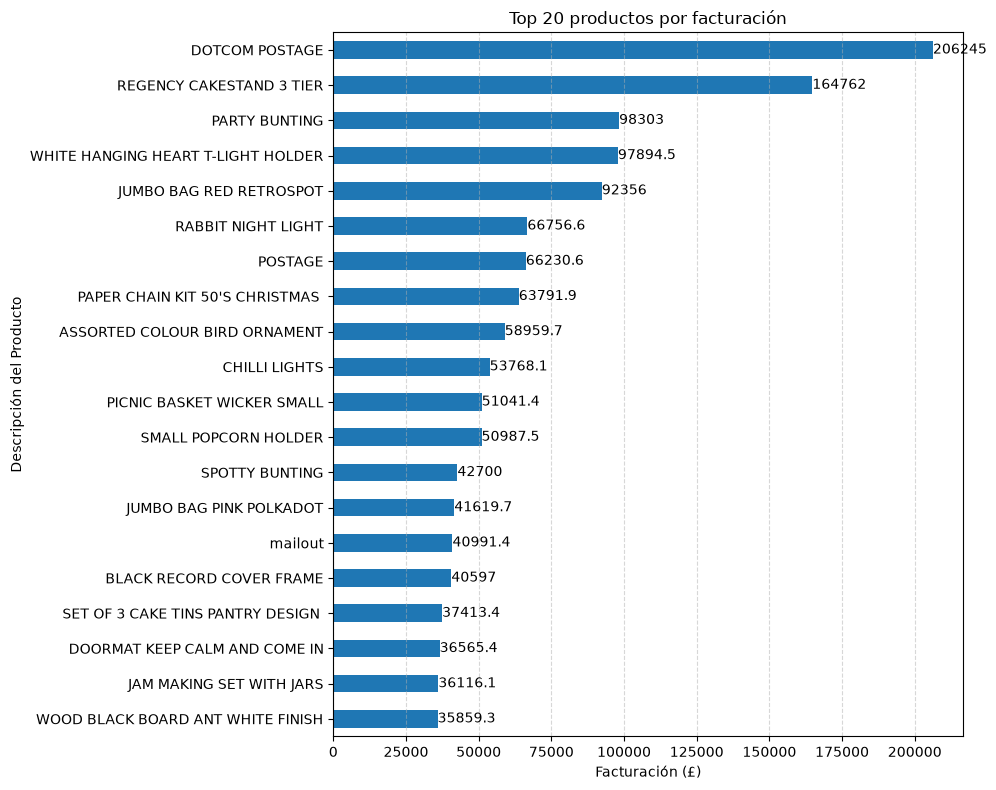

In [28]:
#generamos un gráfico de barras horizontales con los 20 productos con mayor ventas teniendo como eje x la descripción de los productos. 
#Para esto usaremos la función barh de pandas y la función plot de matplotlib. Este debe contener un título y etiquetas en los ejes x e y.
#que contenga plt.tight_layout() y plt.grid()
#el eje y invertido para que el producto con mayor ventas esté en la parte superior del gráfico.
#cada barra tendrá su etiqueta con el valor de ventas correspondiente


fig, ax = plt.subplots(figsize=(10, 8))

top20.plot.barh(
    x="Description",
    y="Revenue",
    ax=ax,
    legend=False
)

ax.set_title("Top 20 productos por facturación")
ax.set_xlabel("Facturación (£)")
ax.set_ylabel("Descripción del Producto")

ax.bar_label(ax.containers[0])

ax.invert_yaxis()

ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()




## Hallazgo 1. Concentración de la facturación

El análisis muestra que los 20 productos con mayor facturación representan aproximadamente el 14 % de los ingresos del negocio. Aunque el catálogo cuenta con más de 4.000 referencias, un grupo reducido de productos concentra una parte importante de la facturación.

Este resultado sugiere que estos productos constituyen activos estratégicos para la empresa y deben ser considerados prioritarios en decisiones relacionadas con inventario, disponibilidad y campañas comerciales.

In [29]:
#crearemos un datafreme llamado pareto  que unicamente que contenga la participación acumulada de cada producto en forma descendente


pareto = (
    df_productos
    .sort_values("Revenue", ascending=False)
    [["Participacion_Acumulada"]]
    .reset_index(drop=True)
)

pareto.index = pareto.index + 1
pareto.index.name = "Ranking"



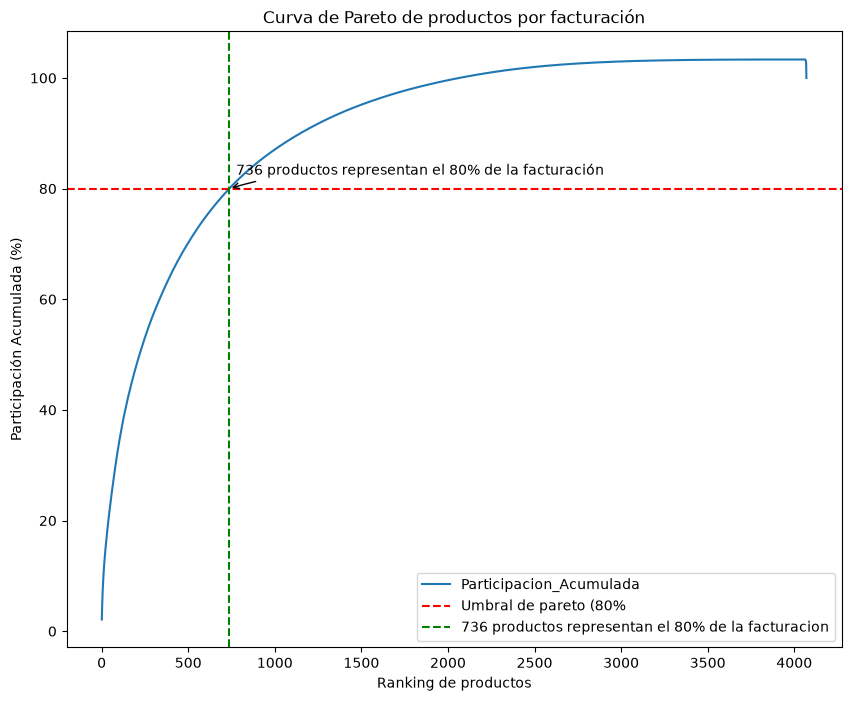

In [30]:
#graficaremos pareto con un gráfico de lineas en donde el eje x sea el índice y el eje y sea la participación acumulada. 
#agregaremos una linea que corte en el eje x en el 80% de participación acumulada y otra linea que corte en el eje y en el 80% de participación acumulada.

fig, ax = plt.subplots(figsize=(10, 8))

pareto.plot(
    y="Participacion_Acumulada",
    ax=ax,
    legend=False
)
ax.set_title("Curva de Pareto de productos por facturación")
ax.set_xlabel("Ranking de productos")
ax.set_ylabel("Participación Acumulada (%)")

# Agregar líneas de corte y etuqueta de linea de corte en el eje x en el 80% de participación acumulada

ax.axhline(y=80, color='r', linestyle='--', label='Umbral de pareto (80%')
ax.axvline(x=pareto[pareto["Participacion_Acumulada"] <= 80].shape[0], color='g', linestyle='--', label='736 productos representan el 80% de la facturacion')
ax.annotate(
    '736 productos representan el 80% de la facturación',
    xy=(pareto[pareto["Participacion_Acumulada"] <= 80].shape[0], 80),
    xytext=(5, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1')
)



ax.legend()
plt.show()


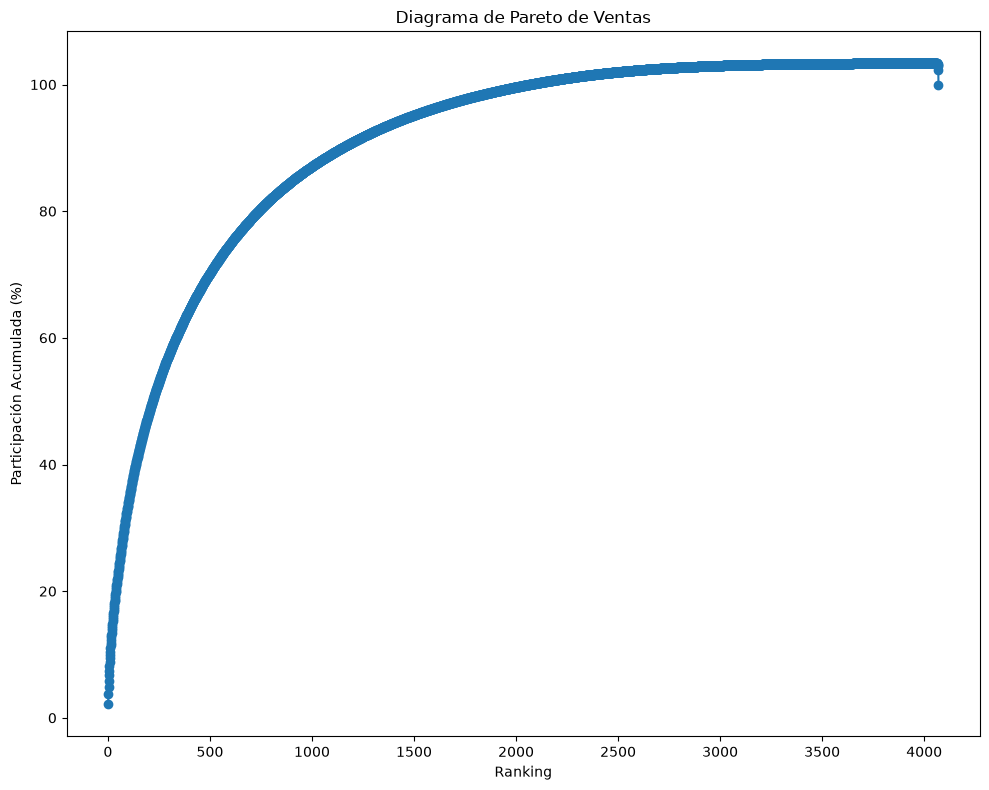

In [31]:
#graficaremos pareto con un gráfico de lineas en donde el eje x sea el índice y el eje y sea la participación acumulada.

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(pareto.index, pareto['Participacion_Acumulada'], marker='o', color='C0')
ax.set_xlabel('Ranking')
ax.set_ylabel('Participación Acumulada (%)')
ax.set_title('Diagrama de Pareto de Ventas')
plt.tight_layout()
plt.show()